# Stiftung Tierärztliche Hochschule Hannover - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Stiftung Tierärztliche Hochschule Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/015qjqf64' -- 'Stiftung Tierärztliche Hochschule Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Stiftung Tierärztliche Hochschule Hannover,"Institute for Animal Nutrition, University of ...",https://openalex.org/W4405559264
1,not assigned,Stiftung Tierärztliche Hochschule Hannover,Science and Innovation for Sustainable Poultry...,https://openalex.org/W4405559264
2,not assigned,Stiftung Tierärztliche Hochschule Hannover,Institute for Terrestrial and Aquatic Wildlife...,https://openalex.org/W4402531402
3,not assigned,Stiftung Tierärztliche Hochschule Hannover,"Institute for Immunology, University of Veteri...",https://openalex.org/W4402028344
4,not assigned,Stiftung Tierärztliche Hochschule Hannover,"Institute for Immunology, University of Veteri...",https://openalex.org/W4402028344


In [26]:
MAPPING_DICT = {
    'Anatomisches Institut': ['anatomy'],
    #'Arbeitsgruppe Vektor-assoziierte Biodiversität und Infektionen': [],
    'Außenstelle für Epidemiologie': ['epidemiolog(ie|y)'],
    'Fachgebiet Allgemeine Radiologie und Medizinische Physik': ['general radiology', 'department of radiology'],
    #'Gesellschaft für Innovative Veterinärdiagnostik (IVD GmbH)': [],
    #'Hochschulbibliothek': [],
    'Institut für Biochemie': ['bio(chemi(e|stry))'],
    'Institut für Biometrie, Epidemiologie und Informationsverarbeitung': ['biometry'],
    'Institut für Immunologie': ['immunolog(ie|y)'],
    'Institut für Lebensmittelqualität und -sicherheit': ['food quality', 'food safety', 'lebensmittelqualität'],
    'Institut für Lebensmitteltoxikologie und Chemische Analytik': ['food toxicology'],
    'Institut für Mikrobiologie': ['mi(k|c)robiolog(ie|y)'],
    'Institut für Parasitologie': ['parasitolog(ie|y)', 'fish disease'],
    'Institut für Pathologie': ['pharma(k|c)olog(ie|y)', 'patholog(ie|y)'],
    'Institut für Pharmakologie, Toxikologie und Pharmazie': ['neurowissenschaften', 'neuroscience'],
    'Institut für Physiologie und Zellbiologie': ['physiologi(sche|cal) chemi(e|stry)', 'physiolog(ie|y|ical)', 'zellbiologie'],
    'Institut für Reproduktionsbiologie': ['reproductive biology', 'reproduktionsbiologie'],
    'Institut für Terrestrische und Aquatische Wildtierforschung': ['wildtierforschung', 'terrestrial'],
    'Institut für Tierernährung': ['animal nutrition', 'tierernährung'],
    'Institut für Tiergenomik': ['animal genomics'],
    'Institut für Tierhygiene, Tierschutz und Nutztierethologie': ['tierhygiene', 'animal hygiene'],
    'Institut für Tierzucht und Vererbungsforschung': ['animal breeding', 'tierzucht'],
    'Institut für Tierökologie': ['animal ecology', 'ecology and evolution', 'tierökologie'],
    'Institut für Virologie': ['virolog(ie|y)'],
    'Institut für Zoologie': ['zoolog(ie|y)', 'zoologisches institut'],
    'Klinik für Geflügel': ['poultry', 'geflügel'],
    'Klinik für Heimtiere, Reptilien, Zier- und Wildvögel': ['reptil(ien|e)'],
    'Klinik für kleine Klauentiere und Forensische Medizin und Ambulatorische Klinik': ['klauentiere', 'forensic', 'clinic for swine'],
    'Klinik für Kleintiere': ['small animal', 'kleintiere', 'neurologie', 'small domestic animals', 'kleintierklinik'],
    'Klinik für Pferde': ['clinic for horses', 'klinik f(ü)?r pferde', 'equine clinic'],
    'Klinik für Rinder': ['clinic for cattle', 'klinik für rinder', 'diseases of cattle', 'cattle clinic'],
    'Lehr- und Forschungsgut Ruthe': ['farm for education( and research ruthe)?', 'forschungsgut ruthe'], #selbst egänzt
    'Reproduktionsmedizinische Einheit der Kliniken': ['biostabilization laboratory', 'reproductive medicine', 'reproduktionsmedizinische'],
    'Research Center for Emerging Infections and Zoonoses (RIZ)': ['zoonos(e|i)s', 'infection genetics'],
    'Zentrum für E-Learning, Didaktik und Ausbildungsforschung': ['e(-|‐)learning', 'clinical skills lab', 'cent(re|er) for teaching'] #selbst ergänzt
}

In [27]:
with open('./mapping_tables_fak/tiho.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [28]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [29]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [30]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Institut für Tierernährung,Stiftung Tierärztliche Hochschule Hannover,"Institute for Animal Nutrition, University of ...",https://openalex.org/W4405559264
1,Klinik für Geflügel,Stiftung Tierärztliche Hochschule Hannover,Science and Innovation for Sustainable Poultry...,https://openalex.org/W4405559264
2,Institut für Terrestrische und Aquatische Wild...,Stiftung Tierärztliche Hochschule Hannover,Institute for Terrestrial and Aquatic Wildlife...,https://openalex.org/W4402531402
3,Institut für Immunologie,Stiftung Tierärztliche Hochschule Hannover,"Institute for Immunology, University of Veteri...",https://openalex.org/W4402028344
4,Institut für Immunologie,Stiftung Tierärztliche Hochschule Hannover,"Institute for Immunology, University of Veteri...",https://openalex.org/W4402028344
...,...,...,...,...
6085,Klinik für Pferde,Stiftung Tierärztliche Hochschule Hannover,Klinik fr Pferde der Stiftung Tierrztliche Hoc...,https://openalex.org/W3012168924
6086,Klinik für Kleintiere,Stiftung Tierärztliche Hochschule Hannover,"Small Animal Clinic, University of Veterinary ...",https://openalex.org/W3018126453
6087,Klinik für Kleintiere,Stiftung Tierärztliche Hochschule Hannover,"Small Animal Clinic, University of Veterinary ...",https://openalex.org/W3018126453
6088,Institut für Physiologie und Zellbiologie,Stiftung Tierärztliche Hochschule Hannover,Department of Physiological Chemistry Universi...,https://openalex.org/W3002357500


In [37]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()

array(['University of Veterinary Medicine Hannover, Hanover, 30559, Lower Saxony, Germany',
       'University of Veterinary Medicine Hannover Foundation, Hannover, Germany',
       'University of Veterinary Medicine Hannover, Hannover, Germany',
       'University of Veterinary Medicine [Hannover]',
       'University of Veterinary Medicine, Hannover, Germany',
       'University of Veterinary Medicine, Hannover',
       'IVD Innovative Veterinary Diagnostics (IVD GmbH), 30926 Seelze, Germany',
       'University of Veterinary Medicine Hannover Victoria Caballero, Texas A&M University at Galveston',
       'University of Veterinary Medicine Hanover, Hanover, Germany',
       'Tierärztliche Hochschule Hannover',
       'University of Veterinary Medicine, Hanover 30559, Germany',
       'University of Veterinary Medicine Hannover, Foundation, Hannover, Germany',
       'DFG-Graduiertenkolleg „Virusdetektion, Pathogenese und Intervention” (VIPER), Stiftung Tierärztliche Hochschule, Hanno

In [38]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Anatomisches Institut,81
1,Außenstelle für Epidemiologie,336
2,Fachgebiet Allgemeine Radiologie und Medizinis...,16
3,Institut für Biochemie,206
4,"Institut für Biometrie, Epidemiologie und Info...",6
5,Institut für Immunologie,110
6,Institut für Lebensmittelqualität und -sicherheit,252
7,Institut für Lebensmitteltoxikologie und Chemi...,12
8,Institut für Mikrobiologie,104
9,Institut für Parasitologie,312


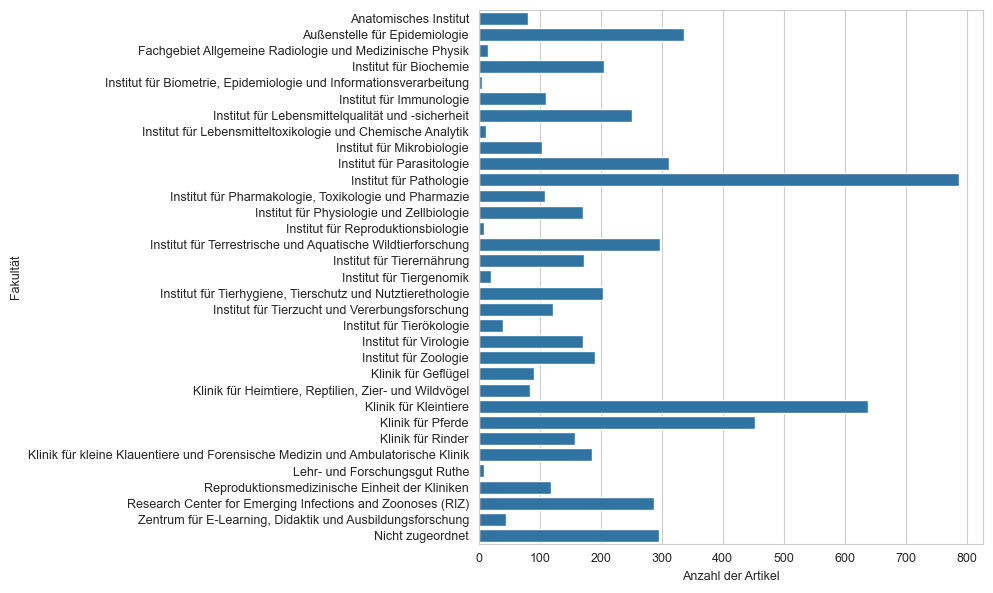

In [39]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [40]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.9513957307060755

In [41]:
MAPPING_DICT_DEPT = {}
MAPPING_DICT_INST = {}

In [42]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Stiftung Tierärztliche Hochschule Hannover'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/tiho.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)